# Group Assignment #3: Clean Notebook and Function + Loop

**Author:** Abigail Adams 

**Group:** Abigail Adams, Jasmine Law, Caleb Huang and Ronald Tien Giang

**Notebook Purpose:** This notebook identifies the population of children living in equity neighborhoods in San Francisco. It also idenfities the percentage of people in those neighborhoods living in poverty. I will be using previously cleaned ACS data and spatial data on San Francisco neighborhoods. 

**Narrative:** 

In 2014, the San Francisco Municipal Transportation Agency (SFMTA) created the Muni Service Equity Policy to identify neighborhoods that would benefit from additonal transportation access based on socioeconomic factors using demographic data using census tracts and city planning neighborhood boundaries. The following criteria was used in selecting neighborhood concentrations of households with low income, concentrations of residents who identify with a race other than white, zero vehicle ownership households, and concentrations of affordable and public housing developments.

A limitation of this index is that it does not account for different age populations, such as families, who may require additional transportation considerations. We chose to use this index because it helps identify locations where people, specifically children, face multiple systemic barriers, including limited transportation access. It is useful in pinpointing areas that are already in line to receive improved transportation support, increasing the feasibility of a potential polciy recommendations that address both transportation and other systemic barriers.

**Data Sources:**

* [ACS](https://www.socialexplorer.com/reports/socialexplorer/en/report/c529bd86-ffc7-11ef-8f8b-e71b92843544)
* [SF Neighborhoods](https://data.sfgov.org/Geographic-Locations-and-Boundaries/SF-Find-Neighborhoods/gfpk-269f/about_data)
* [SF Equity neighborhoods](https://data.sfgov.org/Transportation/Equity-Strategy-Neighborhoods/f8bh-m8ez/about_data)


In [2]:
# import necessary packages
# to read and wrangle data
import pandas as pd

# to create spatial data
import geopandas as gpd

# for basemaps
import contextily as ctx

# Graphics
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [3]:
# import acs data set 
acs = gpd.read_file("data/clean_acs.geojson")

# check
acs.head(2)

,FIPS,Census Tract,Area Name,Workers 16 Years and Over:,"Workers 16 Years and Over: Car, Truck, or Van",Workers 16 Years and Over: Drove Alone,Workers 16 Years and Over: Carpooled,Workers 16 Years and Over: Public Transportation (Includes Taxicab),Workers 16 Years and Over: Motorcycle,Workers 16 Years and Over: Bicycle,...,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available,geometry
0,6075980501,980501,None,9,5,5,0,0,0,0,...,4,0,0,93.0,3.0,0.0,3.0,0.0,0.0,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
1,6075017102,17102,None,2289,727,611,116,519,0,118,...,36,0,0,28.0,48.0,20.0,2.0,0.0,0.0,"MULTIPOLYGON (((-122.45321 37.76825, -122.4516..."


# Part 1: Descriptive Statistics and GTKYD (get to know your data)
We are going to make a subset of the ACS dataset to only include the necessary columns: 

* FIPS
* Total Population
* Age
* geometry
* Median Family Income

These variables are necessary to determine the number of children in each equity neighborhood.

In [4]:
# subset
kids = acs[[
 'FIPS',
 'Total Population',
 'Total Population: Under 18 Years',
 'Median Family Income (In 2023 Inflation Adjusted Dollars)',
 'Median Household Income (In 2023 Inflation Adjusted Dollars)',
 'geometry']].set_axis([
     'FIPS',
     'totalpop',
     'under18',
     'medinc_fam',
     'medinc_hh',
     'geometry'],
                       axis=1)

# check
kids.head(5)

,FIPS,totalpop,under18,medinc_fam,medinc_hh,geometry
0,6075980501,155,0,23500.0,13569.0,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
1,6075017102,3550,578,250001.0,176304.0,"MULTIPOLYGON (((-122.45321 37.76825, -122.4516..."
2,6075012302,2586,108,81375.0,55741.0,"MULTIPOLYGON (((-122.415 37.78745, -122.41335 ..."
3,6075016801,4013,405,250001.0,148173.0,"MULTIPOLYGON (((-122.43235 37.77378, -122.4308..."
4,6075011902,2732,93,51563.0,77241.0,"MULTIPOLYGON (((-122.41246 37.79163, -122.4117..."


Now, we are going to run some descriptive statistics on this subset. 

In [5]:
# check shape 
kids.shape

(241, 6)

There are 241 rows (census tracts) and 6 columns (variables). 

In [6]:
# summary stats 
kids.describe()

,FIPS,totalpop,under18,medinc_fam,medinc_hh
count,2.410000e+02,241.000000,241.000000,225.000000,237.000000
mean,6.075046e+09,3470.211618,476.049793,172292.688889,144302.459916
std,1.370912e+05,1320.544676,325.529091,64059.963431,57967.563281
min,6.075010e+09,49.000000,0.000000,23500.000000,13569.000000
25%,6.075015e+09,2518.000000,214.000000,123512.000000,104648.000000
50%,6.075023e+09,3470.000000,405.000000,178604.000000,146477.000000
75%,6.075033e+09,4197.000000,682.000000,238479.000000,182375.000000
max,6.075981e+09,8415.000000,1762.000000,250001.000000,250001.000000


The `describe()` function gives us basic summary stats on the dataframe. From this output, we learn that: 

* The median family income in each tract is $178,604, which is higher than the average median household income per tract of $146,477.

## Population Under 18
We would like more information about the population under 18 in SF.

1. First, we are going to see how much of the total population that minors make up in SF.
2. We are going to compare the median family income and median household income using a histogram. 

In [7]:
# divide children pop by total pop
total_kids = kids['under18'].sum()
total_pop = kids['totalpop'].sum()

print('There are ' + str(total_kids) + ' total people under 18 in San Francisco.')

# percent of children in total population
percent_child = round(total_kids / total_pop * 100) # calculate the percentage of children in total pop

print('Children make up %' + str(percent_child) + ' of the total population in San Francisco.')


There are 114728 total people under 18 in San Francisco.
Children make up %14 of the total population in San Francisco.


## Median Income in SF: Total Population vs Families

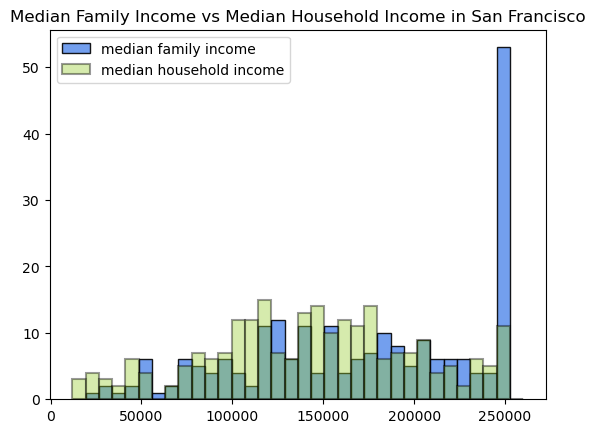

In [8]:
bins = np.linspace(12000, 260000, 35)

# plotting histograms 
plt.hist(kids['medinc_fam'],
         bins = bins,
         alpha=0.9, #  transparency
         color = "cornflowerblue",
         edgecolor='black',
         linewidth=1,
         label='median family income') 
  
plt.hist(kids['medinc_hh'],
         bins = bins, 
         alpha=0.4,
         color = "yellowgreen",
         edgecolor='black',
         linewidth=1.5,
         label='median household income') 
  
plt.legend(loc='best') 
plt.title('Median Family Income vs Median Household Income in San Francisco') 
plt.show()

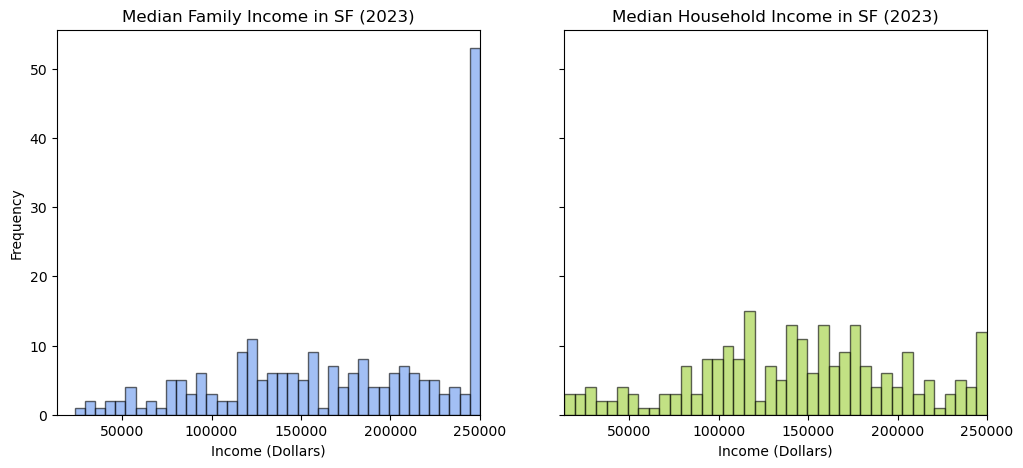

In [9]:
# create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)  
# `sharex=True` and `sharey=True` ensure both plots have the same scale

# med family inc on the left
axes[0].hist(kids['medinc_fam'], 
             bins=40, 
             alpha=0.6, 
             color="cornflowerblue", 
             edgecolor='black', 
             linewidth=1)
axes[0].set_title('Median Family Income in SF (2023)')
axes[0].set_xlabel('Income (Dollars)')
axes[0].set_ylabel('Frequency')

# med household inc on the right
axes[1].hist(kids['medinc_hh'], 
             bins=40, 
             alpha=0.6, 
             color="yellowgreen", 
             edgecolor='black', 
             linewidth=1)
axes[1].set_title('Median Household Income in SF (2023)')
axes[1].set_xlabel('Income (Dollars)')

# set the x-axis range is the same for both plots
xmin = min(kids['medinc_fam'].min(), kids['medinc_hh'].min())
xmax = max(kids['medinc_fam'].max(), kids['medinc_hh'].max())
for ax in axes:
    ax.set_xlim(xmin, xmax)

# Adjust layout
#plt.tight_layout()
plt.show()


## Median Income Distributions

**Median Family Income (Left):**

The distribution of median family income has a significant extremely high incomes, skewing the data to the left. Compared to median household income, median family income has more incomes falling between 125,000 and 200,000. However, there is more fluctuation in incomes that fall between 0 and ~175,000, and the fluctuation appears to decrease after $175,000.

There are also less families with incomes on the lower end compared to median household income.  

**Median Household Income (Right):**

We can see that median household income in SF is slightly skewed to the left but overall  uniformly distributed. Most households have incomes located in the middle sections of the histogram, between 100,000 and 175,000. The fluctuation in median household income appears to be inverse to that seen in median family income. For instance, there is little fluctuation in incomes that fall between 0 and ~175,000, and the fluctuation appears to increase after $175,000. 

**What does this mean for our project?**
It is generally expected that families have higher incomes than households because there are possiblely more people being provided for per income compared to hosueholds with no children. Also, median household income includes family incomes.  

The fluctuation in median family income is most significant for our project. This suggests that there is income inequality in San Francisco. 

# Part 2: Spatial Component

## Neighborhood Analysis

Now, we are going to spatially join the `kids` ACS dataframe to SF neighborhood boundary data. The purpose of this is to see the spatial distribution of poverty in SF for children. This is important for our project because growing up in areas with concentrated poverty (20% or higher) has been seen to have adverse outcomes on children long-term [(Butler & Grabinsky)](https://www.brookings.edu/articles/tackling-the-legacy-of-persistent-urban-inequality-and-concentrated-poverty/). Identifying areas of high poverty and high percentages of child residents can help us target areas where equity interventions that invest in increasing high-quality school access. Targetting school-transportation access interventions in these areas can mitigate the adverse effects of concentrated poverty through improved educational access and school quality.   

In [11]:
# import SF neighborhood data 
hoods = gpd.read_file("data/SF_Find_Neighborhoods_20250314.geojson")

# verify
hoods.head(3)

,link,name,geometry
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937..."
1,,Lake Street,"MULTIPOLYGON (((-122.48715 37.78379, -122.4872..."
2,http://www.nps.gov/prsf/index.htm,Presidio National Park,"MULTIPOLYGON (((-122.47758 37.81099, -122.4771..."


In [13]:
# change name of 'name' column
hoods = hoods.rename(columns={'name': 'neighborhoods'})

hoods.head(3)

,link,neighborhoods,geometry
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937..."
1,,Lake Street,"MULTIPOLYGON (((-122.48715 37.78379, -122.4872..."
2,http://www.nps.gov/prsf/index.htm,Presidio National Park,"MULTIPOLYGON (((-122.47758 37.81099, -122.4771..."


In [33]:
# check dimensions
hoods.shape

(117, 3)

<Axes: >

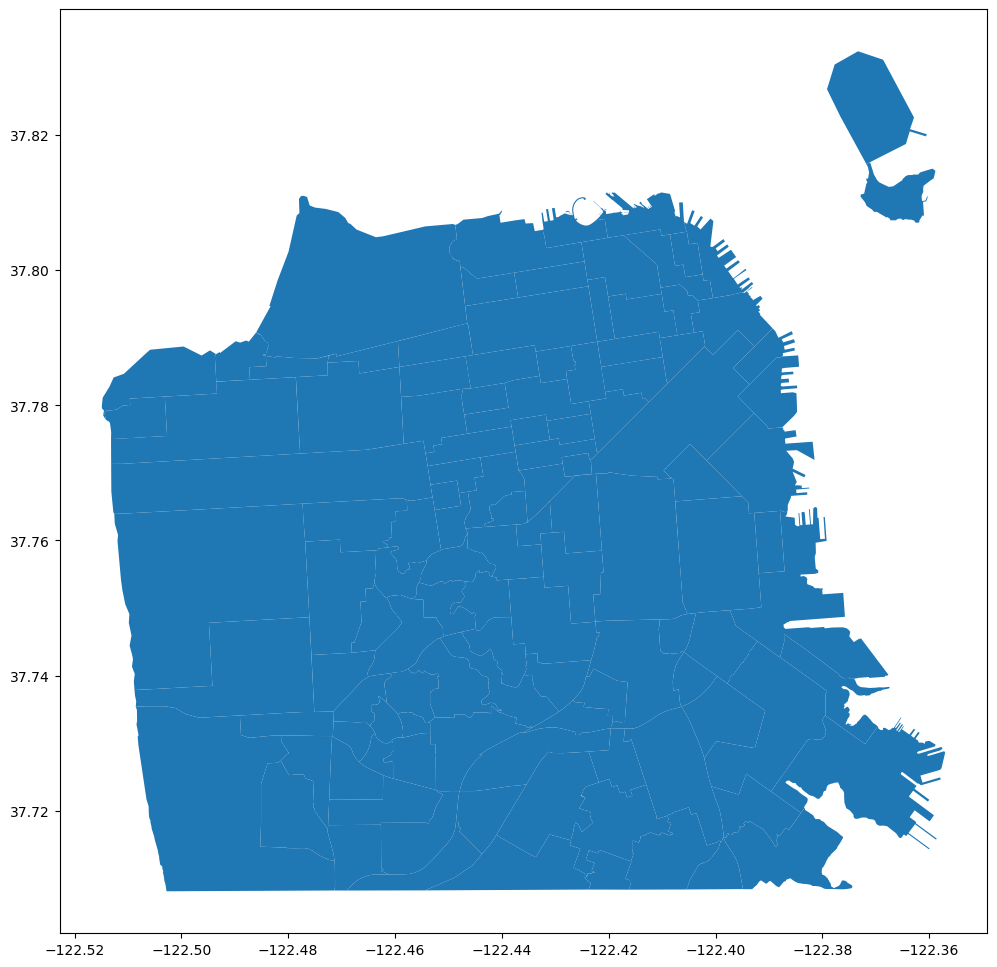

In [14]:
# map neighborhoods 
hoods.plot(figsize=(12,12))

In [120]:
# import equity neighborhood data 
equity = gpd.read_file("data/Equity_Strategy_Neighborhoods_20250313.geojson")

# verify
equity.head()

,com_transi,com_da,zero_veh_h,objectid,data_loaded_at,veh_capita,neighborho,com_carpoo,mta_equitystrategy_nhoods,data_as_of,geometry
0,0,0,0,0,2024-07-30 15:08:37.844,0,Excelsior/Outer Mission,0,1.6044,2022-09-07 20:53:11,"MULTIPOLYGON (((-122.43371 37.71314, -122.4327..."
1,0,0,0,0,2024-07-30 15:08:37.844,0,Ocean View/Ingleside,0,None,2022-09-07 20:53:06,"MULTIPOLYGON (((-122.4531 37.72327, -122.45412..."
2,34,13,82,13,2024-07-30 15:08:37.844,0.11,Chinatown,3,0,2020-07-20 17:58:20,"MULTIPOLYGON (((-122.40881 37.79016, -122.4088..."
3,45,12,74,14,2024-07-30 15:08:37.844,0.12,Downtown/Civic Center,1,0.8858,2020-07-20 17:58:20,"MULTIPOLYGON (((-122.42195 37.78849, -122.4210..."
4,41,26,43,17,2024-07-30 15:08:37.844,0.41000000000000003,Western Addition,5,0,2020-07-20 17:58:20,"MULTIPOLYGON (((-122.42221 37.77291, -122.4243..."


In [121]:
# check dimensions
equity.shape

(9, 11)

In [75]:
# check full list of equity neighborhooods
equity['neighborho'].to_list()

['Excelsior/Outer Mission',
 'Ocean View/Ingleside',
 'Chinatown',
 'Downtown/Civic Center',
 'Western Addition',
 'Mission',
 "Bayview/Hunter's Point",
 'Visitacion Valley',
 'Treasure Island']

There are 9 rows / neighborhoods listed, but 4 neighbhoods have two names. To ensure these names will be recognized before we filter the `hoods` dataset, we are going to manually seperate the names and make a list. 

In [84]:
# make equity neighborhood list
equitylist = ['Excelsior',
 'Outer Mission',
 'Ocean View',
 'Ingleside',
 'Chinatown',
 'Downtown',
 'Civic Center',
 'Western Addition',
 'Mission',
 'Bayview',
 'Hunters Point',
 'Visitacion Valley',
 'Treasure Island']

In [119]:
# check for equity neighbhoods in neighborhood df
ehoods = hoods[hoods["neighborhoods"].isin(equitylist)]

#check
ehoods["neighborhoods"]

20          Civic Center
35       Treasure Island
52               Mission
63             Ingleside
65         Outer Mission
74     Visitacion Valley
77         Hunters Point
85               Bayview
89             Excelsior
96      Western Addition
103            Chinatown
Name: neighborhoods, dtype: object

In [93]:
# make under 18 percentage 
equity_kids["under18_pct"] = equity_kids["under18"] / equity_kids["totalpop"]

#Get citywide total for reference
sf_under18 = equity_kids["under18"].sum()

equity_kids["under18_proportion"] = equity_kids["under18"] / sf_under18

print(equity_kids[["neighborho", "under18_pct", "under18_proportion"]])

                  neighborho  under18_pct  under18_proportion
0          Visitacion Valley     0.000000            0.000000
0    Excelsior/Outer Mission     0.000000            0.000000
2      Downtown/Civic Center     0.041763            0.001467
3                    Mission     0.100922            0.005503
3           Western Addition     0.100922            0.005503
..                       ...          ...                 ...
231         Western Addition     0.121199            0.003791
234                  Mission     0.074574            0.003981
234         Western Addition     0.074574            0.003981
235                  Mission     0.083632            0.003492
236                  Mission     0.041148            0.001033

[161 rows x 3 columns]


<Axes: >

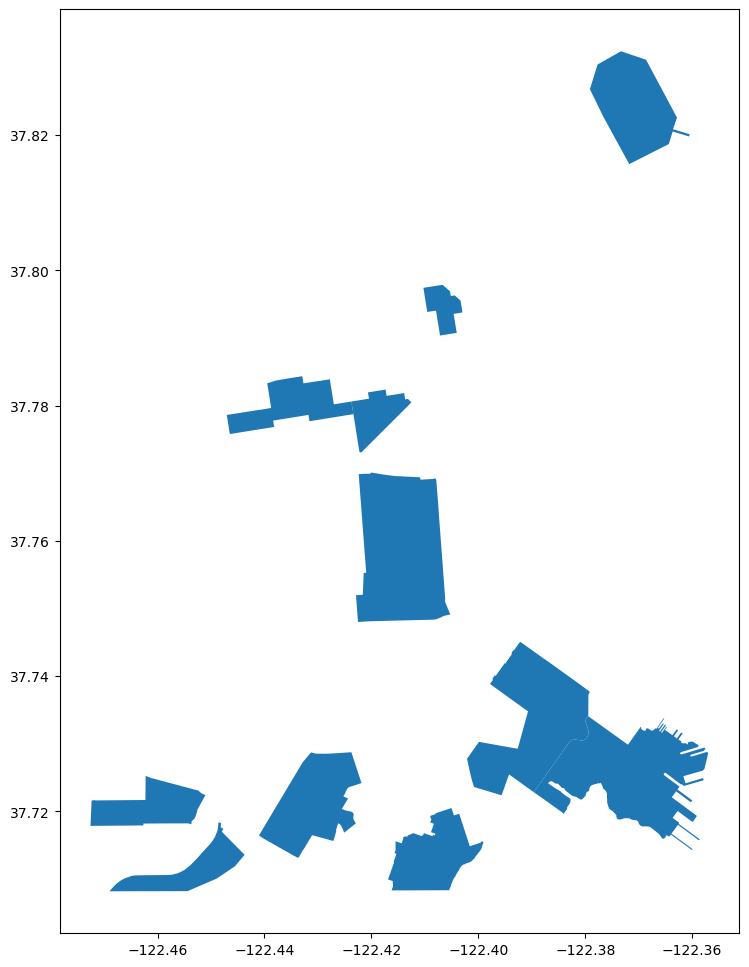

In [92]:
# map equity neighborhoods 
ehoods.plot(figsize=(12,12))

In [137]:
# merge ehoods with kids (ACS) 
equity_under18 = gpd.sjoin(ehoods, kids) #Spatial join points to polygons

# verify 
equity_under18.head()

,link,neighborhoods,geometry,index_right,FIPS,totalpop,under18,medinc_fam,medinc_hh
20,"http://en.wikipedia.org/wiki/Civic_Center,_San...",Civic Center,"MULTIPOLYGON (((-122.41251 37.78048, -122.4219...",81,6075016000,2725,95,141793.0,141304.0
20,"http://en.wikipedia.org/wiki/Civic_Center,_San...",Civic Center,"MULTIPOLYGON (((-122.41251 37.78048, -122.4219...",116,6075017700,2360,267,NaN,178125.0
20,"http://en.wikipedia.org/wiki/Civic_Center,_San...",Civic Center,"MULTIPOLYGON (((-122.41251 37.78048, -122.4219...",143,6075017603,4527,419,NaN,132600.0
20,"http://en.wikipedia.org/wiki/Civic_Center,_San...",Civic Center,"MULTIPOLYGON (((-122.41251 37.78048, -122.4219...",130,6075012405,3878,391,89551.0,107311.0
20,"http://en.wikipedia.org/wiki/Civic_Center,_San...",Civic Center,"MULTIPOLYGON (((-122.41251 37.78048, -122.4219...",215,6075017604,3720,267,117250.0,106438.0


Successful merge! Now, let's check dimensions

In [96]:
# check shape
equity_under18.shape

(103, 9)

In [152]:
# define a function that finds the percentage of children in each equity neighborhood
def under18_percentage (equity_under18, neighborhoods, under18, totalpop):
    
    # groupby neighborhood, add up under18 and total population
    equity_group = equity_under18.groupby(neighborhoods)[[under18, totalpop]].sum().reset_index()

    # Calculate % of under-18s in each neighborhood
    equity_group["percent_under18"] = round((equity_group[under18] / equity_group[totalpop]) * 100)

    return equity_group

under18_table = under18_percentage(equity_under18, 'neighborhoods', 'under18', 'totalpop')

# Print the results
print(under18_table)  # This shows the first few rows


        neighborhoods  under18  totalpop  percent_under18
0             Bayview     8941     38569             23.0
1           Chinatown     1454     18621              8.0
2        Civic Center     3598     42970              8.0
3           Excelsior     8729     47770             18.0
4       Hunters Point     5877     21796             27.0
5           Ingleside     4185     23768             18.0
6             Mission     9143     71237             13.0
7       Outer Mission     5325     31000             17.0
8     Treasure Island      433      2829             15.0
9   Visitacion Valley     4503     25915             17.0
10   Western Addition     4225     44370             10.0


In [170]:
# Function to calculate the percentage of population under 18 in a neighborhood
def under_18_PCT(place, data):
    # make the subset for each equity neighborhood
    subset = data[data["neighborhoods"] == place]  
    
    # calculate total population and population under 18 for each neighborhood
    totalpop_sf = subset["totalpop"].sum() # total population for all census tracts
    under18_sf = subset["under18"].sum() # total population under 18 for all census tracts
    
    # make option for if pop is 0 (cant divide by 0)
    if totalpop_sf > 0:
        percent = (under18_sf / totalpop_sf) * 100
        print(f"{place}: {percent:.2f}% under 18")  # print sentence for result
    else:
        print(f"{place}: No population data available")

# List of neighborhoods you're interested in
neighborhoods = ['Outer Mission', 'Ocean View', 'Ingleside', 'Chinatown', 
                 'Downtown', 'Civic Center', 'Western Addition', 'Mission', 
                 'Bayview', 'Hunters Point', 'Visitacion Valley', 'Treasure Island']

# run function for each equity neighborhood in the list
for neighborhood in neighborhoods:
    under_18_PCT(place=neighborhood, data=equity_under18)

Outer Mission: 17.18% under 18
Ocean View: No population data available
Ingleside: 17.61% under 18
Chinatown: 7.81% under 18
Downtown: No population data available
Civic Center: 8.37% under 18
Western Addition: 9.52% under 18
Mission: 12.83% under 18
Bayview: 23.18% under 18
Hunters Point: 26.96% under 18
Visitacion Valley: 17.38% under 18
Treasure Island: 15.31% under 18


In [173]:
under18_table['percent_under18'].median()

17.0

In [174]:
# check median of children in equity neighborhoods 

under18_table['percent_under18'].median()

17.0

This function and loop tells us what percentage of the population in each equity neighborhood is under 18. There is no data for the Ocean View and Downtown neighborhoods, which may be due to the parks&rec or commercially zones near those areas, respectively.

The percentages range from the lowest of 7.81% in Chinatown to the highest of 26.96% in Hunter's Point. 

**Why is this important for our project?**

As we reported earlier in this notebook, children make up 14% of San Francisco's overall population. However, children are overrepresented in the city's equity neighborhoods which are marked by poverty, low vehicle access, and a concentration of affordable and public housing. With a significant portion of youth living in neighborhoods with limited transportation options and other disadvantaged characterisitics, the lack of accessible public transit can exacerbate other challenges they face by maiking it harder to access resources that could help them advance socioeconomically. These results suggest that equity neighborhoods could be ideal locations to target policy interventions to improve transportation access to high schools in San Francisco. 

**Group Contributions** 

The notebook represents Abigail's code.

Caleb, Ronald, and Jasmine contributed to the group discussion where we decided to look at the percentage of children in equity nieghborhoods. 